# Language Identification Validation: GlotLID v3/v2/v1 vs NLLB-LID

**Tujuan**: validasi LID model fasttext pada NusaX-Senti — bandingkan 4 model:
- **GlotLID v3** (cis-lmu/glotlid `model_v3.bin`): 2102 labels, latest (2024+), excludes macro langs
- **GlotLID v2** (cis-lmu/glotlid `model_v2.bin`): more langs vs v1, cleaned
- **GlotLID v1** (cis-lmu/glotlid `model_v1.bin`): EMNLP 2023 paper version, baseline
- **NLLB-LID** (facebook/fasttext-language-identification): 218 bahasa, dari NLLB project

In [1]:
import fasttext
import fasttext.FastText
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download
from pathlib import Path
from collections import Counter

# Fix NumPy 2.x compatibility issue with fasttext
# fasttext uses np.array(obj, copy=False) which is deprecated in NumPy 2.x
_original_predict = fasttext.FastText._FastText.predict

def _patched_predict(self, text, k=1, threshold=0.0, on_unicode_error="strict"):
    if isinstance(text, list):
        all_labels, all_probs = [], []
        for t in text:
            l, p = _patched_predict(self, t, k, threshold, on_unicode_error)
            all_labels.append(l)
            all_probs.append(p)
        return all_labels, all_probs
    else:
        pairs = self.f.predict(text, k, threshold, on_unicode_error)
        if pairs:
            probs, labels = zip(*pairs)
        else:
            probs, labels = ([], ())
        return labels, np.asarray(probs)

fasttext.FastText._FastText.predict = _patched_predict

y:\Michh\Python\Projects\MAGenerator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download dan load 4 models: GlotLID v3, v2, v1, NLLB-LID
glotlid_v3_path = hf_hub_download(repo_id='cis-lmu/glotlid', filename='model_v3.bin')
glotlid_v2_path = hf_hub_download(repo_id='cis-lmu/glotlid', filename='model_v2.bin')
glotlid_v1_path = hf_hub_download(repo_id='cis-lmu/glotlid', filename='model_v1.bin')
nllb_path       = hf_hub_download(repo_id='facebook/fasttext-language-identification', filename='model.bin')

print(f'GlotLID v3: {glotlid_v3_path}')
print(f'GlotLID v2: {glotlid_v2_path}')
print(f'GlotLID v1: {glotlid_v1_path}')
print(f'NLLB-LID:   {nllb_path}')

MODELS = {
    'GlotLID-v3': fasttext.load_model(glotlid_v3_path),
    'GlotLID-v2': fasttext.load_model(glotlid_v2_path),
    'GlotLID-v1': fasttext.load_model(glotlid_v1_path),
    'NLLB-LID':   fasttext.load_model(nllb_path),
}
print(f'\nLoaded models: {list(MODELS.keys())}')

y:\Michh\Python\Projects\MAGenerator\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\micha\.cache\huggingface\hub\models--cis-lmu--glotlid. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


GlotLID v3: C:\Users\micha\.cache\huggingface\hub\models--cis-lmu--glotlid\snapshots\85cd6716494360367b75f642b5bc78667605d0b4\model_v3.bin
GlotLID v2: C:\Users\micha\.cache\huggingface\hub\models--cis-lmu--glotlid\snapshots\85cd6716494360367b75f642b5bc78667605d0b4\model_v2.bin
GlotLID v1: C:\Users\micha\.cache\huggingface\hub\models--cis-lmu--glotlid\snapshots\85cd6716494360367b75f642b5bc78667605d0b4\model_v1.bin
NLLB-LID:   C:\Users\micha\.cache\huggingface\hub\models--facebook--fasttext-language-identification\snapshots\3af127d4124fc58b75666f3594bb5143b9757e78\model.bin

Loaded models: ['GlotLID-v3', 'GlotLID-v2', 'GlotLID-v1', 'NLLB-LID']


In [3]:
# Sanity check: predict sample text on both models
sample = 'Sian bagasan roha do hami mandok horas tu hamu sude.'  # Toba Batak (bbc)
for name, model in MODELS.items():
    labels, scores = model.predict(sample, k=3)
    print(f'\n[{name}]')
    for label, score in zip(labels, scores):
        print(f'  {label}: {score:.4f}')


[GlotLID-v3]
  __label__akb_Latn: 0.9958
  __label__bbc_Latn: 0.0043
  __label__dtp_Latn: 0.0000

[GlotLID-v2]
  __label__akb_Latn: 0.9981
  __label__bbc_Latn: 0.0019
  __label__tet_Latn: 0.0000

[GlotLID-v1]
  __label__bbc: 0.9674
  __label__akb: 0.0326
  __label__bts: 0.0000

[NLLB-LID]
  __label__bjn_Latn: 0.9933
  __label__ind_Latn: 0.0036
  __label__bam_Latn: 0.0018


In [4]:
# Semua bahasa NusaX-Senti
# GlotLID menggunakan format: __label__<iso639-3>_<script>
TARGET_LANGS = {
    "ace": "__label__ace_Latn",  # Acehnese
    "ban": "__label__ban_Latn",  # Balinese
    "bbc": "__label__bbc_Latn",  # Toba Batak
    "bjn": "__label__bjn_Latn",  # Banjarese
    "bug": "__label__bug_Latn",  # Buginese
    "eng": "__label__eng_Latn",  # English
    "ind": "__label__ind_Latn",  # Indonesian
    "jav": "__label__jav_Latn",  # Javanese
    "mad": "__label__mad_Latn",  # Madurese
    "min": "__label__min_Latn",  # Minangkabau
    "nij": "__label__nij_Latn",  # Ngaju
    "sun": "__label__sun_Latn",  # Sundanese
}

DATA_DIR = Path("../data/nusax_senti")
SPLITS = ["train", "valid", "test"]

In [5]:
def predict_language(text: str, model, k: int = 3):
    clean_text = text.replace('\n', ' ').strip()
    if not clean_text:
        return [], []
    labels, scores = model.predict(clean_text, k=k)
    return list(labels), list(scores)


def evaluate_lid_on_nusax(lang_code: str, split: str, model):
    expected_label = TARGET_LANGS[lang_code]
    csv_path = DATA_DIR / lang_code / f'{split}.csv'
    df = pd.read_csv(csv_path)

    results = []
    for _, row in df.iterrows():
        text = str(row['text'])
        labels, scores = predict_language(text, model, k=3)

        top1_label = labels[0] if labels else ''
        top1_score = scores[0] if scores else 0.0
        is_correct = (top1_label == expected_label)
        in_top3 = expected_label in labels

        results.append({
            'id': row['id'],
            'text': text[:80] + '...' if len(text) > 80 else text,
            'sentiment': row['label'],
            'expected': expected_label,
            'predicted': top1_label,
            'confidence': round(top1_score, 4),
            'correct_top1': is_correct,
            'in_top3': in_top3,
            'top3_labels': str(labels),
            'top3_scores': str([round(s, 4) for s in scores]),
        })

    return pd.DataFrame(results)

## Validasi LID pada Data NusaX Asli (4 model)

Jalankan 4 model (GlotLID v3, v2, v1, NLLB-LID) pada **semua split** (train/valid/test) dari **semua bahasa** NusaX-Senti.

In [6]:
# Jalankan evaluasi untuk semua model di MODELS
all_results = {name: {} for name in MODELS}
summary_rows = []

for model_name, model in MODELS.items():
    print(f'\n{"="*60}')
    print(f'Running {model_name}')
    print(f'{"="*60}')
    for lang_code in TARGET_LANGS:
        for split in SPLITS:
            key = f'{lang_code}_{split}'
            df_result = evaluate_lid_on_nusax(lang_code, split, model)
            all_results[model_name][key] = df_result

            n_total = len(df_result)
            n_correct_top1 = df_result['correct_top1'].sum()
            n_in_top3 = df_result['in_top3'].sum()
            avg_confidence = df_result['confidence'].mean()
            acc_top1 = n_correct_top1 / n_total * 100
            acc_top3 = n_in_top3 / n_total * 100

            summary_rows.append({
                'Model': model_name,
                'Language': lang_code,
                'Split': split,
                'Total': n_total,
                'Top-1 Correct': n_correct_top1,
                'Top-1 Accuracy (%)': round(acc_top1, 2),
                'Top-3 Accuracy (%)': round(acc_top3, 2),
                'Avg Confidence': round(avg_confidence, 4),
            })
            print(f'  [{lang_code} {split}] Top-1: {acc_top1:.1f}% | Top-3: {acc_top3:.1f}% | Conf: {avg_confidence:.3f}')

print('\nDone!')


Running GlotLID-v3
  [ace train] Top-1: 95.4% | Top-3: 99.0% | Conf: 0.951
  [ace valid] Top-1: 97.0% | Top-3: 99.0% | Conf: 0.976
  [ace test] Top-1: 93.5% | Top-3: 97.5% | Conf: 0.950
  [ban train] Top-1: 83.0% | Top-3: 94.8% | Conf: 0.878
  [ban valid] Top-1: 85.0% | Top-3: 97.0% | Conf: 0.920
  [ban test] Top-1: 83.2% | Top-3: 93.8% | Conf: 0.880
  [bbc train] Top-1: 91.0% | Top-3: 97.2% | Conf: 0.905
  [bbc valid] Top-1: 92.0% | Top-3: 97.0% | Conf: 0.885
  [bbc test] Top-1: 91.0% | Top-3: 95.8% | Conf: 0.920
  [bjn train] Top-1: 95.0% | Top-3: 97.2% | Conf: 0.956
  [bjn valid] Top-1: 97.0% | Top-3: 97.0% | Conf: 0.968
  [bjn test] Top-1: 95.0% | Top-3: 97.2% | Conf: 0.963
  [bug train] Top-1: 93.6% | Top-3: 98.2% | Conf: 0.944
  [bug valid] Top-1: 97.0% | Top-3: 99.0% | Conf: 0.954
  [bug test] Top-1: 94.0% | Top-3: 98.8% | Conf: 0.951
  [eng train] Top-1: 96.4% | Top-3: 99.2% | Conf: 0.956
  [eng valid] Top-1: 100.0% | Top-3: 100.0% | Conf: 0.977
  [eng test] Top-1: 97.8% | Top

In [7]:
# Summary: 4-way comparison
df_summary = pd.DataFrame(summary_rows)

print('=' * 80)
print('LID VALIDATION SUMMARY (NusaX-Senti)')
print('=' * 80)
display(df_summary)

# Rata-rata per (model × bahasa)
print('\n--- Rata-rata per Bahasa per Model ---')
avg_per_lang = df_summary.groupby(['Model', 'Language']).agg({
    'Total': 'sum',
    'Top-1 Correct': 'sum',
    'Top-1 Accuracy (%)': 'mean',
    'Top-3 Accuracy (%)': 'mean',
    'Avg Confidence': 'mean',
}).round(2)
display(avg_per_lang)

# Side-by-side: 4 model + delta
print('\n--- Comparison: Top-1 Accuracy (%) per bahasa ---')
comparison = df_summary.groupby(['Language', 'Model'])['Top-1 Accuracy (%)'].mean().unstack().round(2)
col_order = [c for c in ['GlotLID-v3', 'GlotLID-v2', 'GlotLID-v1', 'NLLB-LID'] if c in comparison.columns]
comparison = comparison[col_order]
if 'GlotLID-v3' in comparison.columns and 'GlotLID-v2' in comparison.columns:
    comparison['Δ (v3-v2)'] = (comparison['GlotLID-v3'] - comparison['GlotLID-v2']).round(2)
if 'GlotLID-v2' in comparison.columns and 'GlotLID-v1' in comparison.columns:
    comparison['Δ (v2-v1)'] = (comparison['GlotLID-v2'] - comparison['GlotLID-v1']).round(2)
if 'GlotLID-v3' in comparison.columns and 'NLLB-LID' in comparison.columns:
    comparison['Δ (v3-NLLB)'] = (comparison['GlotLID-v3'] - comparison['NLLB-LID']).round(2)
display(comparison)

# Macro avg per model
print('\n--- Macro Average per Model ---')
macro = df_summary.groupby('Model').agg({
    'Top-1 Accuracy (%)': 'mean',
    'Top-3 Accuracy (%)': 'mean',
    'Avg Confidence': 'mean',
}).round(2)
display(macro)

LID VALIDATION SUMMARY (NusaX-Senti)


,Model,Language,Split,Total,Top-1 Correct,Top-1 Accuracy (%),Top-3 Accuracy (%),Avg Confidence
0,GlotLID-v3,ace,train,500,477,95.40,99.0,0.9509
1,GlotLID-v3,ace,valid,100,97,97.00,99.0,0.9757
2,GlotLID-v3,ace,test,400,374,93.50,97.5,0.9502
3,GlotLID-v3,ban,train,500,415,83.00,94.8,0.8783
4,GlotLID-v3,ban,valid,100,85,85.00,97.0,0.9201
...,...,...,...,...,...,...,...,...
139,NLLB-LID,nij,valid,100,0,0.00,0.0,0.6346
140,NLLB-LID,nij,test,400,0,0.00,0.0,0.6420
141,NLLB-LID,sun,train,500,460,92.00,98.6,0.9476
142,NLLB-LID,sun,valid,100,94,94.00,97.0,0.9335



--- Rata-rata per Bahasa per Model ---


Total  Top-1 Correct  Top-1 Accuracy (%)  \
Model      Language                                             
GlotLID-v1 ace        1000              0                0.00   
           ban        1000              0                0.00   
           bbc        1000              0                0.00   
           bjn        1000              0                0.00   
           bug        1000              0                0.00   
           eng        1000              0                0.00   
           ind        1000              0                0.00   
           jav        1000              0                0.00   
           mad        1000              0                0.00   
           min        1000              0                0.00   
           nij        1000              0                0.00   
           sun        1000              0                0.00   
GlotLID-v2 ace        1000            975               97.90   
           ban        1000            901               90.83   
           bbc        1000            913               90.65   
           bjn        1000            961               96.30   
           bug        1000            960               96.75   
           eng        1000            980               98.32   
           ind        1000            960               95.45   
           jav        1000            933               93.95   
           mad        1000            692               68.87   
           min        1000            968               97.42   
           nij        1000            533               55.58   
           sun        1000            972               97.18   
GlotLID-v3 ace        1000            948               95.30   
           ban        1000            833               83.75   
           bbc        1000            911               91.33   
           bjn        1000            952               95.67   
           bug        1000            941               94.87   
           eng        1000            973               98.05   
           ind        1000            721               72.00   
           jav        1000            939               94.47   
           mad        1000            973               97.77   
           min        1000            966               96.75   
           nij        1000            351               36.00   
           sun        1000            970               97.22   
NLLB-LID   ace        1000            983               98.50   
           ban        1000            664               67.48   
           bbc        1000              0                0.00   
           bjn        1000            962               96.95   
           bug        1000            986               98.75   
           eng        1000            993               99.50   
           ind        1000            949               94.85   
           jav        1000            953               95.30   
           mad        1000              0                0.00   
           min        1000            270               26.75   
           nij        1000              0                0.00   
           sun        1000            929               93.25   

                     Top-3 Accuracy (%)  Avg Confidence  
Model      Language                                      
GlotLID-v1 ace                     0.00            0.96  
           ban                     0.00            0.88  
           bbc                     0.00            0.94  
           bjn                     0.00            0.96  
           bug                     0.00            0.94  
           eng                     0.00            0.99  
           ind                     0.00            0.94  
           jav                     0.00            0.95  
           mad                     0.00            0.50  
           min                     0.00            0.97  
           nij                     0.00            0.54  
           sun  


--- Comparison: Top-1 Accuracy (%) per bahasa ---


Model,GlotLID-v3,GlotLID-v2,GlotLID-v1,NLLB-LID,Δ (v3-v2),Δ (v2-v1),Δ (v3-NLLB)
Language,,,,,,,
ace,95.30,97.90,0.0,98.50,-2.60,97.90,-3.20
ban,83.75,90.83,0.0,67.48,-7.08,90.83,16.27
bbc,91.33,90.65,0.0,0.00,0.68,90.65,91.33
bjn,95.67,96.30,0.0,96.95,-0.63,96.30,-1.28
bug,94.87,96.75,0.0,98.75,-1.88,96.75,-3.88
eng,98.05,98.32,0.0,99.50,-0.27,98.32,-1.45
ind,72.00,95.45,0.0,94.85,-23.45,95.45,-22.85
jav,94.47,93.95,0.0,95.30,0.52,93.95,-0.83
mad,97.77,68.87,0.0,0.00,28.90,68.87,97.77



--- Macro Average per Model ---


,Top-1 Accuracy (%),Top-3 Accuracy (%),Avg Confidence
Model,,,
GlotLID-v1,0.00,0.00,0.88
GlotLID-v2,89.93,95.29,0.91
GlotLID-v3,87.76,96.04,0.92
NLLB-LID,64.28,69.94,0.83


## Analisis Error: Kalimat Salah Diprediksi

Untuk tiap bahasa (train split), lihat:
- Bahasa apa yang sering muncul sebagai mis-prediction
- Sample kalimat yang salah diklasifikasi

Bandingkan pola error antara GlotLID dan NLLB-LID.

In [8]:
for model_name in MODELS:
    print(f'\n{"#"*80}')
    print(f'# {model_name} ERROR ANALYSIS (train split)')
    print(f'{"#"*80}')
    for lang_code in TARGET_LANGS:
        df_result = all_results[model_name][f'{lang_code}_train']
        errors = df_result[~df_result['correct_top1']]

        print(f'\n[{lang_code.upper()}] {len(errors)} misclassified / {len(df_result)}')

        if len(errors) == 0:
            print('  Perfect accuracy.')
            continue

        pred_dist = Counter(errors['predicted'].values)
        print(f'  Mispredicted as (top 5):')
        for label, count in pred_dist.most_common(5):
            lang = label.replace('__label__', '')
            print(f'    {lang}: {count} ({count/len(errors)*100:.1f}%)')


################################################################################
# GlotLID-v3 ERROR ANALYSIS (train split)
################################################################################

[ACE] 23 misclassified / 500
  Mispredicted as (top 5):
    bew_Latn: 10 (43.5%)
    sun_Latn: 4 (17.4%)
    mad_Latn: 1 (4.3%)
    ind_Latn: 1 (4.3%)
    ksh_Latn: 1 (4.3%)

[BAN] 85 misclassified / 500
  Mispredicted as (top 5):
    bew_Latn: 39 (45.9%)
    jav_Latn: 20 (23.5%)
    ind_Latn: 6 (7.1%)
    mui_Latn: 3 (3.5%)
    zsm_Latn: 3 (3.5%)

[BBC] 45 misclassified / 500
  Mispredicted as (top 5):
    akb_Latn: 17 (37.8%)
    mui_Latn: 3 (6.7%)
    zsm_Latn: 3 (6.7%)
    min_Latn: 3 (6.7%)
    bts_Latn: 3 (6.7%)

[BJN] 25 misclassified / 500
  Mispredicted as (top 5):
    bew_Latn: 9 (36.0%)
    min_Latn: 3 (12.0%)
    ind_Latn: 3 (12.0%)
    ljp_Latn: 2 (8.0%)
    mhy_Latn: 2 (8.0%)

[BUG] 32 misclassified / 500
  Mispredicted as (top 5):
    mak_Latn: 18 (56.2%)
    mad_Latn:

## Distribusi Confidence: 4 model

Visualisasi distribusi confidence untuk kalimat correct vs wrong, per bahasa, per model. Tiap model satu baris (GlotLID v3, v2, v1, NLLB-LID dari atas ke bawah).

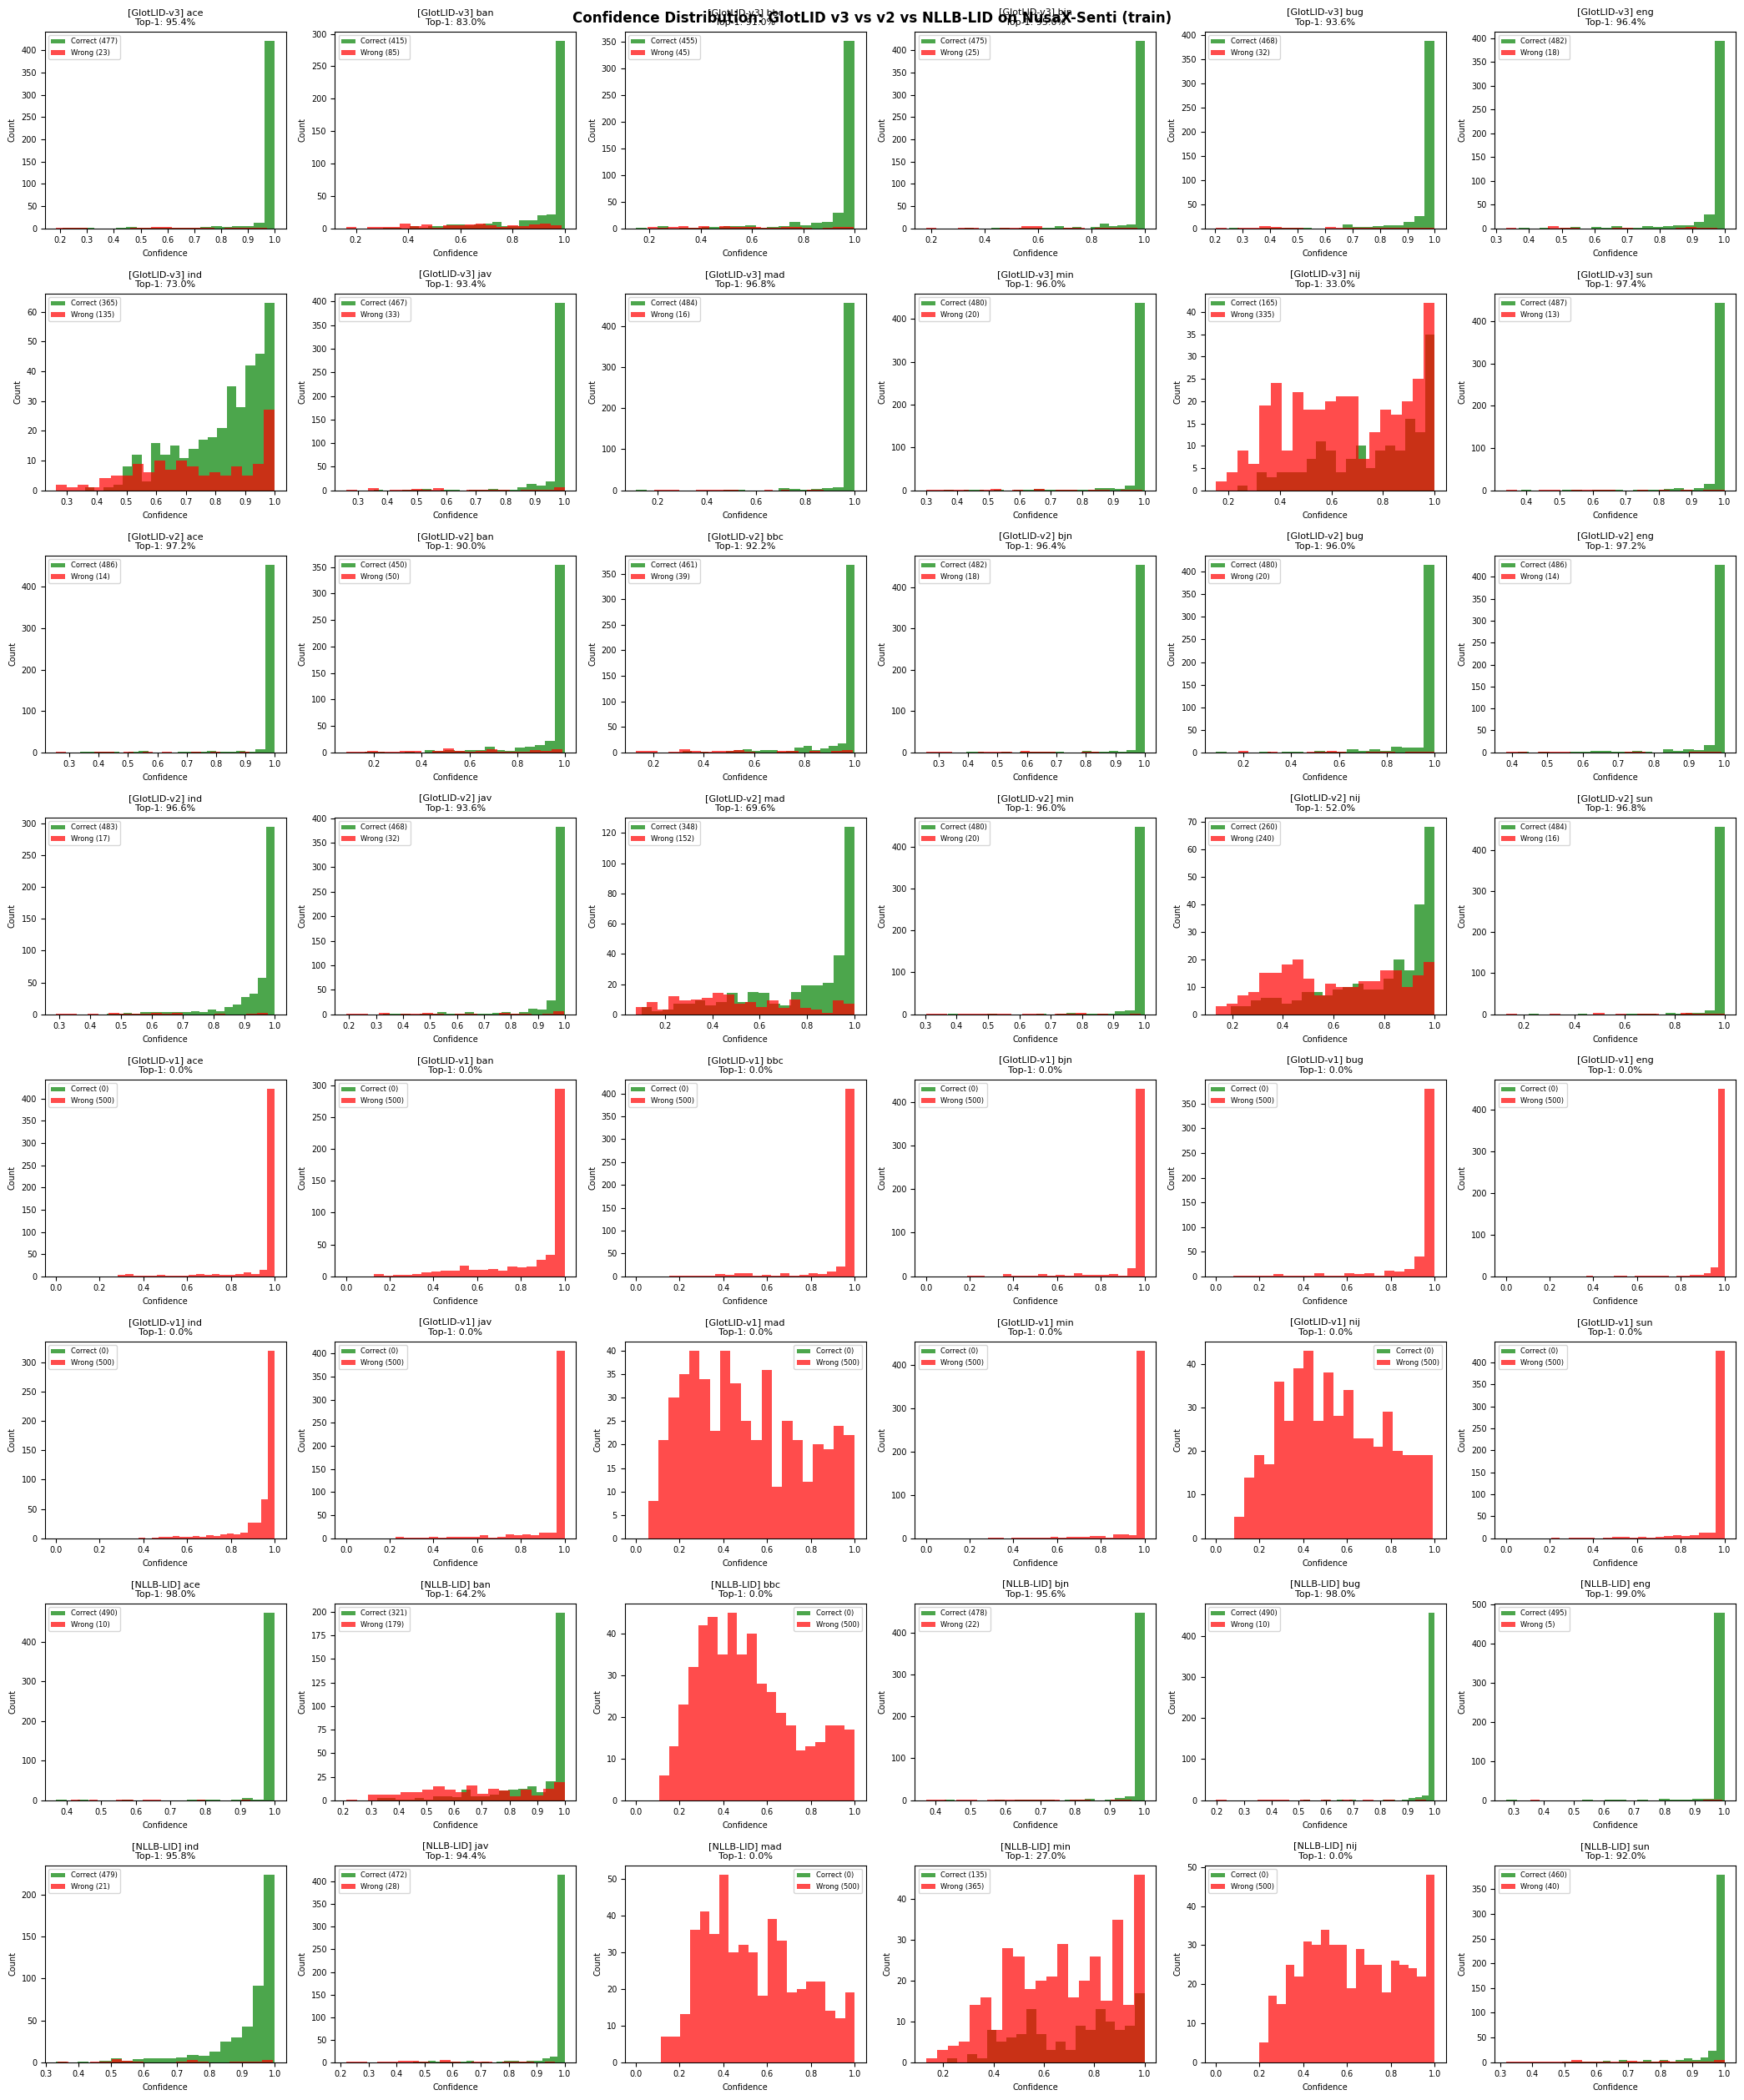

In [9]:
import matplotlib.pyplot as plt

lang_names = {
    'ace': 'Acehnese', 'ban': 'Balinese', 'bbc': 'Toba Batak',
    'bjn': 'Banjarese', 'bug': 'Buginese', 'eng': 'English',
    'ind': 'Indonesian', 'jav': 'Javanese', 'mad': 'Madurese',
    'min': 'Minangkabau', 'nij': 'Ngaju', 'sun': 'Sundanese',
}

# Plot grid: N models (rows) × N langs (cols, wrap to 6)
n_models = len(MODELS)
n_langs = len(TARGET_LANGS)
cols = 6
rows_per_model = (n_langs + cols - 1) // cols
total_rows = n_models * rows_per_model

fig, axes = plt.subplots(total_rows, cols, figsize=(3.5 * cols, 3.2 * total_rows))

for model_idx, model_name in enumerate(MODELS.keys()):
    for lang_idx, lang_code in enumerate(TARGET_LANGS):
        row = model_idx * rows_per_model + lang_idx // cols
        col = lang_idx % cols
        ax = axes[row, col]

        df_result = all_results[model_name][f'{lang_code}_train']
        correct = df_result[df_result['correct_top1']]['confidence']
        wrong = df_result[~df_result['correct_top1']]['confidence']
        acc = len(correct) / len(df_result) * 100

        ax.hist(correct, bins=20, alpha=0.7, label=f'Correct ({len(correct)})', color='green')
        if len(wrong) > 0:
            ax.hist(wrong, bins=20, alpha=0.7, label=f'Wrong ({len(wrong)})', color='red')

        ax.set_title(f'[{model_name}] {lang_code}\nTop-1: {acc:.1f}%', fontsize=8)
        ax.set_xlabel('Confidence', fontsize=7)
        ax.set_ylabel('Count', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)

plt.suptitle('Confidence Distribution: GlotLID v3 vs v2 vs NLLB-LID on NusaX-Senti (train)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()